# 01 - Exploratory Data Analysis
Chess positions dataset (`nikitricky/chess-positions`, Lichess-sourced).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

df = pd.read_csv('../data/raw/positions.csv', low_memory=False)
df.shape

(1091078, 17)

In [ ]:
df.head()

,fen,playing,score,mate,depth,game_id,date,time,white,black,white_result,black_result,white_elo,black_elo,opening,time_control,termination
0,rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR ...,e2e4,-35.0,NaN,20,j1dkb5dw,2012.12.31,23:01:03,BFG9k,mamalak,1,0,1639,1403,French Defense: Normal Variation,600+8,Normal
1,rnbqkbnr/pppp1ppp/4p3/8/4P3/8/PPPP1PPP/RNBQKBN...,e7e6,36.0,NaN,22,j1dkb5dw,2012.12.31,23:01:03,BFG9k,mamalak,1,0,1639,1403,French Defense: Normal Variation,600+8,Normal
2,rnbqkbnr/pppp1ppp/4p3/8/3PP3/8/PPP2PPP/RNBQKBN...,d2d4,-27.0,NaN,24,j1dkb5dw,2012.12.31,23:01:03,BFG9k,mamalak,1,0,1639,1403,French Defense: Normal Variation,600+8,Normal
3,rnbqkbnr/p1pp1ppp/1p2p3/8/3PP3/8/PPP2PPP/RNBQK...,b7b6,81.0,NaN,20,j1dkb5dw,2012.12.31,23:01:03,BFG9k,mamalak,1,0,1639,1403,French Defense: Normal Variation,600+8,Normal
4,rnbqkbnr/p1pp1ppp/1p2p3/8/3PP3/P7/1PP2PPP/RNBQ...,a2a3,-65.0,NaN,22,j1dkb5dw,2012.12.31,23:01:03,BFG9k,mamalak,1,0,1639,1403,French Defense: Normal Variation,600+8,Normal


## Basic structure and missingness

In [ ]:
df.dtypes

fen              object
playing          object
score           float64
mate            float64
depth             int64
game_id          object
date             object
time             object
white            object
black            object
white_result     object
black_result     object
white_elo        object
black_elo        object
opening          object
time_control     object
termination      object
dtype: object

In [ ]:
df.isna().sum().sort_values(ascending=False)

mate            981566
score           109512
fen                  0
white_result         0
time_control         0
opening              0
black_elo            0
white_elo            0
black_result         0
white                0
black                0
playing              0
time                 0
date                 0
game_id              0
depth                0
termination          0
dtype: int64

## Score / mate
`score` is the Stockfish centipawn eval; `mate` holds a mate-in-N distance instead when Stockfish found a forced mate (in which case `score` is null). Check how often that happens and what the raw distributions look like before we decide on a unification/capping rule.

In [ ]:
print('rows with score:', df['score'].notna().sum())
print('rows with mate:', df['mate'].notna().sum())
print('rows with neither:', ((df['score'].isna()) & (df['mate'].isna())).sum())

rows with score: 981566
rows with mate: 109512
rows with neither: 0


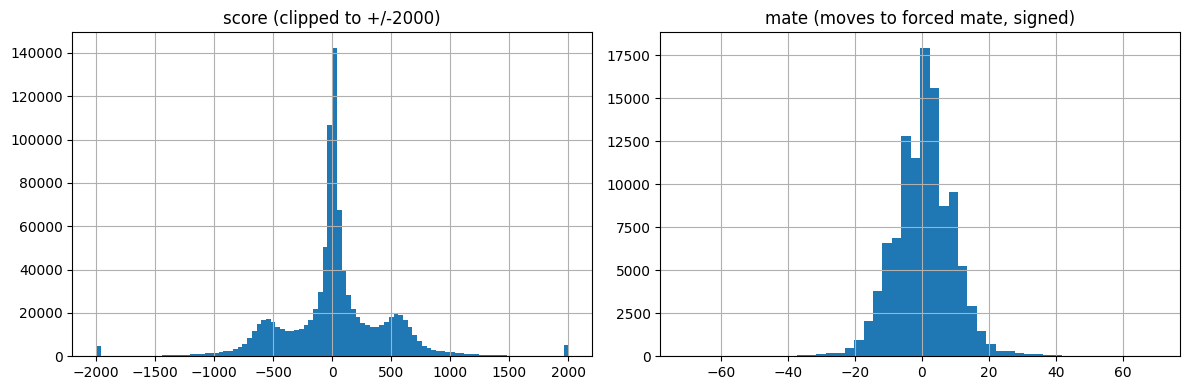

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['score'].clip(-2000, 2000).hist(bins=100, ax=axes[0])
axes[0].set_title('score (clipped to +/-2000)')
df['mate'].hist(bins=50, ax=axes[1])
axes[1].set_title('mate (moves to forced mate, signed)')
plt.tight_layout()

## Outcome / draw encoding
Confirm how `white_result` / `black_result` encode win/loss/draw.

In [ ]:
print(df['white_result'].value_counts(dropna=False))
print()
print(df['black_result'].value_counts(dropna=False))

white_result
1      534144
0      497170
1/2     59764
Name: count, dtype: int64

black_result
0      534144
1      497170
1/2     59764
Name: count, dtype: int64


## Elo columns
`white_elo`/`black_elo` loaded as mixed-type/object columns rather than clean numeric — inspect what the non-numeric values actually are.

In [ ]:
for col in ['white_elo', 'black_elo']:
    non_numeric = df[col][pd.to_numeric(df[col], errors='coerce').isna() & df[col].notna()]
    print(col, '-> non-numeric unique values:', non_numeric.unique()[:20])

white_elo -> non-numeric unique values: ['?']


black_elo -> non-numeric unique values: ['?']


## Positions per game
Needed for a game-level (leakage-safe) train/test split.

In [ ]:
positions_per_game = df.groupby('game_id').size()
print('number of games:', positions_per_game.shape[0])
positions_per_game.describe()

number of games: 16643


count    16643.000000
mean        65.557772
std         32.948054
min          2.000000
25%         43.000000
50%         61.000000
75%         84.000000
max        244.000000
dtype: float64

Text(0, 0.5, 'games')

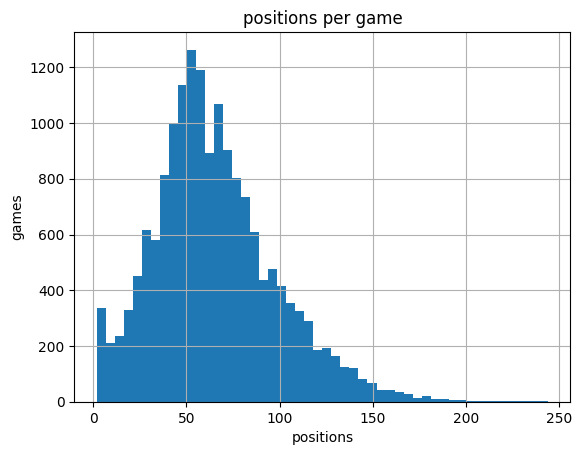

In [ ]:
positions_per_game.hist(bins=50)
plt.title('positions per game')
plt.xlabel('positions')
plt.ylabel('games')